# The Formal Capture Gap: Why Isn't Someone Already Doing This?

## The Question

Notebook 01 estimated USD 260–520 million in recoverable metal value sitting in Malaysia's e-waste stream. Malaysia's formal, government-tracked collection system captures a specific, measurable amount of that stream. How big is the gap, and does a large gap actually mean there's an open business opportunity, or does it mean something else is already happening to the rest of it?

## The Answer

Formal household e-waste collection (2,459 tonnes in 2021) is **well under 1% of Malaysia's estimated total e-waste generation** (364,000 tonnes in 2019) by weight. That gap is real and large, but this notebook argues it should not be read as "USD 250+ million sitting unclaimed for whoever moves first." Malaysia has an active **informal** e-waste recycling sector that already collects and processes a meaningful share of discarded electronics outside government tracking; informal collectors were paying around RM20/kg for copper as of the source cited here, undercutting formal recyclers' trading price. The honest framing is narrower than "huge opportunity": the *formal, government-visible* system is capturing very little, but that does not mean the underlying material value is going unrecovered; it may mean informal actors are already capturing a real share of it, at prices formal entrants would have to compete against.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

generation = pd.read_csv('../data/processed/ewaste_generation_estimate.csv')
collection = pd.read_csv('../data/processed/formal_collection.csv')

generation_tonnes = generation['tonnes_generated'].iloc[0]
collected_tonnes = collection['tonnes_collected'].iloc[0]
capture_share_pct = collected_tonnes / generation_tonnes * 100

print(f'Estimated total e-waste generated (2019): {generation_tonnes:,.0f} tonnes')
print(f'Formal household e-waste collected (2021): {collected_tonnes:,.0f} tonnes')
print(f'Formal collection as share of total generation: {capture_share_pct:.2f}%')

Estimated total e-waste generated (2019): 364,000 tonnes
Formal household e-waste collected (2021): 2,459 tonnes
Formal collection as share of total generation: 0.68%


In [2]:
# House chart style v2: consulting-exhibit conventions (MBB-style):
# gray for context series, one or two accent colors for what the title is
# actually about, direct end-of-line/bar labels instead of a legend box.
ACCENT_1 = '#2a78d6'   # primary accent, the series the title is about
ACCENT_2 = '#eb6834'   # secondary accent; used only for genuine two-way comparisons
                        # or a title that names two co-equal findings
GRAY = '#9a9a95'        # de-emphasized / context series, same family, faded out
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#ececea', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.7,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, consulting-deck style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)

def end_label(ax, x, y, text, color, weight='semibold', va='center', offset=8):
    """Direct label at a line's endpoint, replacing a legend box."""
    ax.annotate(text, xy=(x, y), xytext=(offset, 0), textcoords='offset points',
                 va=va, ha='left', fontsize=10.5, fontweight=weight, color=color)


## Visualizing the scale mismatch

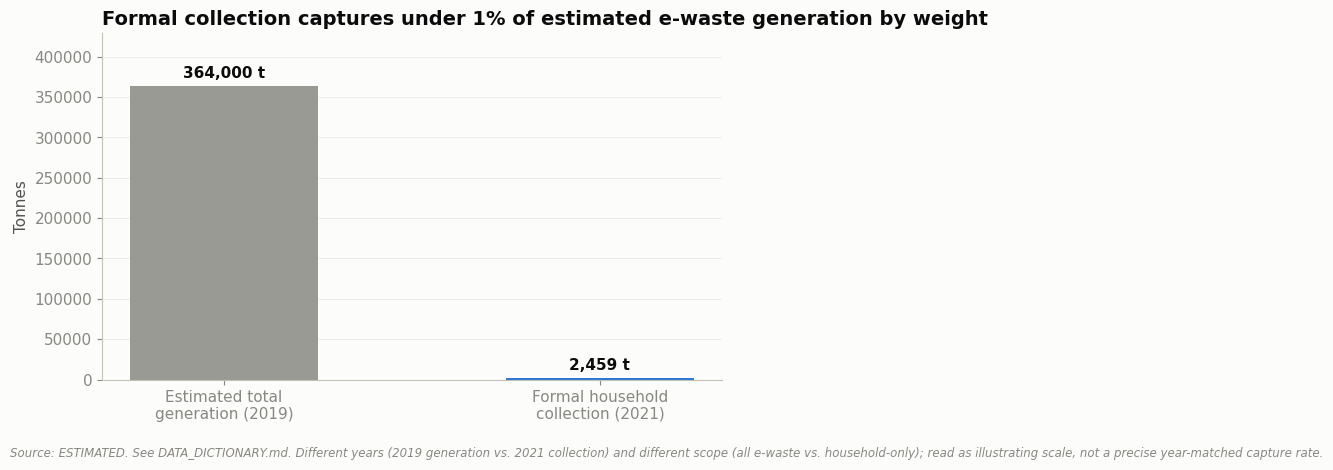

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
categories = ['Estimated total\ngeneration (2019)', 'Formal household\ncollection (2021)']
values = [generation_tonnes, collected_tonnes]
colors = [GRAY, ACCENT_1]

bars = ax.bar(categories, values, color=colors, width=0.5, edgecolor='none')
for bar, v in zip(bars, values):
    ax.annotate(f'{v:,.0f} t', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 6), textcoords='offset points', ha='center', fontsize=11, fontweight='semibold')

ax.set_title('Formal collection captures under 1% of estimated e-waste generation by weight', loc='left')
ax.set_ylabel('Tonnes')
ax.set_ylim(top=max(values) * 1.18)

add_source(ax.figure, 'Source: ESTIMATED. See DATA_DICTIONARY.md. Different years (2019 generation vs. 2021 '
                       'collection) and different scope (all e-waste vs. household-only); read as illustrating '
                       'scale, not a precise year-matched capture rate.')
plt.show()

## Why this probably isn't "money sitting on the table"

A large formal-capture gap is easy to read as an open business opportunity. Three real reasons that reading is likely wrong, or at least incomplete:

1. **An active informal sector already exists and already prices this material.** Monash Lens (2023) documents Malaysia's informal e-waste recycling sector paying around RM20/kg (roughly USD 5/kg at the time) for copper from households; below what licensed businesses pay, but still a functioning market. A new formal entrant isn't collecting from a vacuum; it's competing against an established informal price and existing collector relationships.
2. **Processing costs are not in this analysis at all.** Notebook 01's USD 260–520 million is *gross* recoverable value; what the metal is worth once extracted. Actual extraction (collection logistics, sorting, smelting/refining) has real costs this analysis has no data for. The gap between gross value and net profit could be small or could erase the opportunity entirely; this notebook cannot say which.
3. **"Formal collection" measures government visibility, not material loss.** Low formal collection numbers could mean e-waste is landfilled and the value is genuinely lost, or it could mean the material is already being recovered informally and simply isn't counted. This analysis cannot distinguish between those two very different scenarios with the data available.

## Strategic Recommendation

- **A business should not treat the formal-capture gap alone as evidence of an untapped opportunity.** The real question is whether formal recycling can out-compete the informal sector on price and reliability, not whether a gap exists in government statistics.
- **The more promising angle is displacing or formalizing existing informal flows, not "capturing what's currently wasted."** If most of the gap is already informally recovered, the business opportunity is about better economics, safety, and traceability versus informal collectors, not about discovering unclaimed material.
- **Before committing capital, the missing piece is processing economics, not resource sizing.** Notebook 01 answers "is there enough value here to matter" (yes). This notebook answers "is the formal system capturing it" (barely). Neither answers "would a new formal entrant actually turn a profit"; that requires real collection and processing cost data this analysis does not have.

## Confidence & Caveats

- **The 2019-vs-2021 year mismatch and household-only scope of the collection figure are real limitations**, not adjusted for here, restated from Notebook 01 because they directly affect the headline "under 1%" claim in this notebook.
- **The informal-sector claims in this notebook rest on a single secondary source** (Monash Lens, 2023) describing one pricing data point (copper, ~RM20/kg), not a comprehensive account of informal-sector scale or economics. This notebook argues the informal sector is *relevant*, not that it precisely explains the entire gap.
- **This notebook does not, and cannot with the data available, state what share of the "missing" 99%+ is informally recovered versus genuinely lost to landfill or export.** That is the single most important unanswered question a real investment decision would need, stated directly rather than implied away.

## Why Is This Happening? (Context)

*Qualitative, secondary-sourced context on the mechanism behind this notebook's capture-gap finding; kept separate from the ESTIMATED figures above. Full citations in [`references/SOURCES.md`](../references/SOURCES.md).*

Formal collection stays under 1% largely because Malaysia has no legislative framework specifically covering household e-waste, unlike industrial/commercial scheduled waste, which is tightly regulated, household disposal is voluntary, and licensed formal recyclers are outnumbered by the volume of e-waste actually generated each year. Into that gap steps an active informal sector: door-to-door scavengers on modified bikes collect e-waste directly from households and pay the household for it, which is a more convenient and immediately rewarding option than seeking out a formal drop-off point most people don't know exists. Low public awareness of authorized recycling schemes, and some distrust of formal collection agents, reinforce the pattern. None of this means the "missing" material is lost; it means it is very likely being captured by an existing informal market that this project's PUBLIC/ESTIMATED data cannot see or measure directly, which is precisely the point this notebook's core finding is making.

**Sources:** [Monash Lens, "Understanding Malaysia's informal e-waste recycling sector"](https://lens.monash.edu/understanding-the-informal-e-waste-recycling-sector-in-malaysia/); [BusinessToday, "Informal e-waste recycling in Malaysia: Where do your household electronics end up?"](https://www.businesstoday.com.my/2023/01/15/informal-e-waste-recycling-in-malaysia-where-do-your-household-electronics-end-up/).